# NWI Encoding Strategy Comparison (exp403-405, full dataset)

**Context:** Trains 6 RF probability models total, comparing 3 different
National Wetlands Inventory (NWI) encoding strategies across 2 point
datasets (full ~102K points and the 0-20cm-dropped ~57K point set --
this notebook is the *full dataset* half, exp403/404/405; the
0-20cm-dropped counterpart is exp406/407/408, referenced elsewhere).

**The 3 NWI strategies compared** (see Covariate Curation, "National
Wetlands Inventory (NWI)"):
- `3class`: one-hot encode all 3 Cowardin groupings (non-wetland /
  wetland / lowland conifer)
- `binary`: collapse to non-wetland vs. any-wetland
- `none`: NWI excluded entirely

**Finding documented in the write-up:** NWI contributed minimally when
tested on the full dataset (this notebook) -- AUC differences between
the three strategies were negligible here. The binary encoding was
ultimately kept in the final model (exp410, trained on the 0-20cm-
dropped dataset) because it preserved meaningful wetland/non-wetland
discrimination without creating the polygon-edge artifacts seen with
other categorical layers.

Cell-by-cell breakdown is annotated inline via the existing
`# Cell N — ...` comments already present in each code cell below.


In [1]:
# Cell 1 — Imports and config
import os, json, pickle
import numpy as np
import pandas as pd
from sklearn.ensemble import RandomForestClassifier
from sklearn.model_selection import StratifiedKFold
from sklearn.metrics import roc_auc_score, average_precision_score
import matplotlib.pyplot as plt
from datetime import date

BASE         = '/scratch.global/ocon0444/peat_modeling'
CORR_JSON    = os.path.join(BASE, '05_results/correlation_analysis/reduced_covariate_list.json')
CATALOG      = os.path.join(BASE, 'MODEL_CATALOG.csv')
TARGET_COL   = 'peat_binary'
RANDOM_STATE = 42

# The 2 input datasets
DATASETS = {
    'FINAL': os.path.join(BASE, '00_data/processed/binary_peat_features_extracted.csv'),
    '0_20_dropped': os.path.join(BASE, '00_data/processed/binary_peat_features_0_20_dropped.csv'),
}

# exp403/404/405 map to FINAL, exp406/407/408 map to 0_20_dropped
# Wait — using 403/404/405 for FINAL and overwriting
# 3 NWI variants per dataset = 6 models total
# exp403 = FINAL + NWI 3-class
# exp404 = FINAL + NWI binary (0 vs 1+2)
# exp405 = FINAL + no NWI
# exp406 = 0-20cm dropped + NWI 3-class
# exp407 = 0-20cm dropped + NWI binary (0 vs 1+2)
# exp408 = 0-20cm dropped + no NWI

EXPERIMENTS = {
    'exp403': {'dataset': 'FINAL',        'nwi': '3class',  'description': 'Binary presence - FINAL pts - NWI 3-class (0/1/2)'},
    'exp404': {'dataset': 'FINAL',        'nwi': 'binary',  'description': 'Binary presence - FINAL pts - NWI binary (0 vs 1+2)'},
    'exp405': {'dataset': 'FINAL',        'nwi': 'none',    'description': 'Binary presence - FINAL pts - no NWI'},
    'exp406': {'dataset': '0_20_dropped', 'nwi': '3class',  'description': 'Binary presence - 0-20cm dropped - NWI 3-class (0/1/2)'},
    'exp407': {'dataset': '0_20_dropped', 'nwi': 'binary',  'description': 'Binary presence - 0-20cm dropped - NWI binary (0 vs 1+2)'},
    'exp408': {'dataset': '0_20_dropped', 'nwi': 'none',    'description': 'Binary presence - 0-20cm dropped - no NWI'},
}

print('Config loaded.')
print(f'Experiments: {list(EXPERIMENTS.keys())}')

Config loaded.
Experiments: ['exp403', 'exp404', 'exp405', 'exp406', 'exp407', 'exp408']


In [2]:
# Cell 2 — Build base feature list from correlation filter
with open(CORR_JSON) as f:
    corr_data = json.load(f)

# Columns to always exclude
EXCLUDE_ALWAYS = [
    'lat', 'long', 'point_id', 'depb', 'peat_binary',
    # old zero-filled TC columns from before extraction
    's2_spring_TCB', 's2_spring_TCG', 's2_spring_TCW',
    's2_summer_TCB', 's2_summer_TCG', 's2_summer_TCW',
]
PEAT_MAP_EXACT   = ['gNATSGO_MN_26915', 'npc_peatland_indicator_10m']
PEAT_MAP_PREFIXES = [
    'histosols_10m_', 'MN_organic_soils_classified_',
    'MN_ANY_organic_component_',
]
ONEHOT_PREFIXES = ['quaternary_geology_', 'pennockLandformClass_', 'geomorphons_']
TC_COLS = [
    'tc_spring_TCB', 'tc_spring_TCG', 'tc_spring_TCW',
    'tc_summer_TCB', 'tc_summer_TCG', 'tc_summer_TCW',
    'tc_fall_TCB',   'tc_fall_TCG',   'tc_fall_TCW',
]

def is_peat_map(c):
    return c in PEAT_MAP_EXACT or any(c.startswith(p) for p in PEAT_MAP_PREFIXES)

# Reduced continuous from correlation filter — exclude leakers and peat maps
reduced_continuous = [
    c for c in corr_data['kept_continuous']
    if c not in EXCLUDE_ALWAYS and not is_peat_map(c)
]

print(f'Reduced continuous (post-correlation filter, no leakers): {len(reduced_continuous)}')
print(f'TC cols to add: {TC_COLS}')
print(f'Total continuous + TC: {len(reduced_continuous) + len(TC_COLS)}')

Reduced continuous (post-correlation filter, no leakers): 30
TC cols to add: ['tc_spring_TCB', 'tc_spring_TCG', 'tc_spring_TCW', 'tc_summer_TCB', 'tc_summer_TCG', 'tc_summer_TCW', 'tc_fall_TCB', 'tc_fall_TCG', 'tc_fall_TCW']
Total continuous + TC: 39


In [3]:
# Cell 3 — Load both datasets and verify columns
dataframes = {}
for ds_name, csv_path in DATASETS.items():
    df = pd.read_csv(csv_path, low_memory=False)
    print(f'{ds_name}: {df.shape}')
    print(f'  Target: {df[TARGET_COL].value_counts(dropna=False).to_dict()}')

    # Verify TC cols present
    missing_tc = [c for c in TC_COLS if c not in df.columns]
    if missing_tc:
        print(f'  WARNING missing TC cols: {missing_tc}')
    else:
        print(f'  All 9 TC cols present')

    # Verify NWI cols
    nwi_cols = [c for c in df.columns if c.startswith('mn_nwi_cowardin_')]
    print(f'  NWI cols: {nwi_cols}')

    dataframes[ds_name] = df

print('\nDatasets loaded.')

FINAL: (102403, 166)
  Target: {0.0: 46737, nan: 42036, 1.0: 13630}
  All 9 TC cols present
  NWI cols: ['mn_nwi_cowardin_0', 'mn_nwi_cowardin_1', 'mn_nwi_cowardin_2']
0_20_dropped: (96744, 166)
  Target: {0.0: 46737, nan: 39610, 1.0: 10397}
  All 9 TC cols present
  NWI cols: ['mn_nwi_cowardin_0', 'mn_nwi_cowardin_1', 'mn_nwi_cowardin_2']

Datasets loaded.


In [4]:
# Cell 4 — Helper: prepare X and build NWI columns per experiment
def get_nwi_cols(df, nwi_type):
    """Return NWI columns for the given experiment type."""
    if nwi_type == '3class':
        # All 3 classes as separate one-hot cols
        return ['mn_nwi_cowardin_0', 'mn_nwi_cowardin_1', 'mn_nwi_cowardin_2']
    elif nwi_type == 'binary':
        # Keep _0 and _1, add merged _1_2 col (class 2 treated as 1)
        # mn_nwi_cowardin_0 = no wetland
        # mn_nwi_merged_1_2 = any wetland (1 or 2)
        df['mn_nwi_merged_1_2'] = (
            (df['mn_nwi_cowardin_1'] == 1) | (df['mn_nwi_cowardin_2'] == 1)
        ).astype(int)
        return ['mn_nwi_cowardin_0', 'mn_nwi_merged_1_2']
    elif nwi_type == 'none':
        return []

def prepare_X(df, feature_cols):
    X = df[feature_cols].apply(pd.to_numeric, errors='coerce')
    X = X.fillna(X.median())
    return X

print('Helpers defined.')

Helpers defined.


In [5]:
# Cell 5 — Train all 6 models
results = {}

for exp_id, cfg in EXPERIMENTS.items():
    print(f"\n{'='*60}")
    print(f"{exp_id}: {cfg['description']}")
    print('='*60)

    df = dataframes[cfg['dataset']].copy()

    # Get one-hot cols from this df
    onehot_cols = [c for c in df.columns
                   if any(c.startswith(p) for p in ONEHOT_PREFIXES)]

    # Get NWI cols (may add merged col to df)
    nwi_cols = get_nwi_cols(df, cfg['nwi'])

    # Full feature list: reduced continuous + TC + one-hot + NWI
    feature_cols = reduced_continuous + TC_COLS + onehot_cols + nwi_cols
    feature_cols = [c for c in feature_cols if c in df.columns]

    print(f"  Continuous (corr filtered) : {len(reduced_continuous)}")
    print(f"  TC bands                   : {len(TC_COLS)}")
    print(f"  One-hot                    : {len(onehot_cols)}")
    print(f"  NWI                        : {len(nwi_cols)} {nwi_cols}")
    print(f"  Total features             : {len(feature_cols)}")

    X = prepare_X(df, feature_cols)
    y = df[TARGET_COL]

    # Drop NaN targets
    valid_idx = y.notna()
    X = X[valid_idx].reset_index(drop=True)
    y = y[valid_idx].reset_index(drop=True)
    print(f"  Training rows: {len(y):,}  (dropped {(~valid_idx).sum():,} NaN targets)")
    print(f"  Class balance: {y.value_counts().to_dict()}")

    cv = StratifiedKFold(n_splits=5, shuffle=True, random_state=RANDOM_STATE)
    fold_results = []
    models = []

    for fold, (train_idx, val_idx) in enumerate(cv.split(X, y)):
        X_train, X_val = X.iloc[train_idx], X.iloc[val_idx]
        y_train, y_val = y.iloc[train_idx], y.iloc[val_idx]

        rf = RandomForestClassifier(
            n_estimators=200,
            class_weight='balanced',
            n_jobs=-1,
            random_state=RANDOM_STATE
        )
        rf.fit(X_train, y_train)

        y_prob = rf.predict_proba(X_val)[:, 1]
        auc = roc_auc_score(y_val, y_prob)
        ap  = average_precision_score(y_val, y_prob)

        fold_results.append({'fold': fold, 'roc_auc': auc, 'avg_precision': ap})
        models.append(rf)
        print(f"  Fold {fold}  ROC-AUC={auc:.4f}  Avg-Precision={ap:.4f}")

    fold_df  = pd.DataFrame(fold_results)
    mean_auc = fold_df['roc_auc'].mean()
    mean_ap  = fold_df['avg_precision'].mean()
    print(f"\n  Mean ROC-AUC:       {mean_auc:.4f} +/- {fold_df['roc_auc'].std():.4f}")
    print(f"  Mean Avg-Precision: {mean_ap:.4f} +/- {fold_df['avg_precision'].std():.4f}")

    results[exp_id] = {
        'models': models,
        'fold_df': fold_df,
        'feature_cols': feature_cols,
        'mean_roc_auc': round(mean_auc, 4),
        'mean_avg_precision': round(mean_ap, 4),
        'description': cfg['description'],
        'dataset': cfg['dataset'],
        'nwi_type': cfg['nwi'],
        'n_samples': len(y),
    }


exp403: Binary presence - FINAL pts - NWI 3-class (0/1/2)
  Continuous (corr filtered) : 30
  TC bands                   : 9
  One-hot                    : 70
  NWI                        : 3 ['mn_nwi_cowardin_0', 'mn_nwi_cowardin_1', 'mn_nwi_cowardin_2']
  Total features             : 112
  Training rows: 60,367  (dropped 42,036 NaN targets)
  Class balance: {0.0: 46737, 1.0: 13630}
  Fold 0  ROC-AUC=0.9577  Avg-Precision=0.8953
  Fold 1  ROC-AUC=0.9566  Avg-Precision=0.8923
  Fold 2  ROC-AUC=0.9575  Avg-Precision=0.8937
  Fold 3  ROC-AUC=0.9566  Avg-Precision=0.8928
  Fold 4  ROC-AUC=0.9550  Avg-Precision=0.8876

  Mean ROC-AUC:       0.9567 +/- 0.0011
  Mean Avg-Precision: 0.8924 +/- 0.0029

exp404: Binary presence - FINAL pts - NWI binary (0 vs 1+2)
  Continuous (corr filtered) : 30
  TC bands                   : 9
  One-hot                    : 70
  NWI                        : 2 ['mn_nwi_cowardin_0', 'mn_nwi_merged_1_2']
  Total features             : 111
  Training rows: 60,367

In [6]:
# Cell 6 — Save models
for exp_id, res in results.items():
    model_dir = os.path.join(BASE, f'03_models/{exp_id}')
    os.makedirs(model_dir, exist_ok=True)

    for i, model in enumerate(res['models']):
        with open(os.path.join(model_dir, f'model_fold_{i}.pkl'), 'wb') as f:
            pickle.dump(model, f)

    res['fold_df'].to_csv(os.path.join(model_dir, 'cv_results.csv'), index=False)

    with open(os.path.join(model_dir, 'feature_list.json'), 'w') as f:
        json.dump({
            'features': res['feature_cols'],
            'n_features': len(res['feature_cols']),
            'nwi_type': res['nwi_type'],
            'dataset': res['dataset'],
        }, f, indent=2)

    print(f"{exp_id}: saved {len(res['models'])} fold models to {model_dir}")

exp403: saved 5 fold models to /scratch.global/ocon0444/peat_modeling/03_models/exp403
exp404: saved 5 fold models to /scratch.global/ocon0444/peat_modeling/03_models/exp404
exp405: saved 5 fold models to /scratch.global/ocon0444/peat_modeling/03_models/exp405
exp406: saved 5 fold models to /scratch.global/ocon0444/peat_modeling/03_models/exp406
exp407: saved 5 fold models to /scratch.global/ocon0444/peat_modeling/03_models/exp407
exp408: saved 5 fold models to /scratch.global/ocon0444/peat_modeling/03_models/exp408


In [7]:
# Cell 7 — Update MODEL_CATALOG.csv
# Remove exp403/404/405 old entries AND any exp406/407/408 if they exist
OVERWRITE_IDS = ['exp403', 'exp404', 'exp405', 'exp406', 'exp407', 'exp408']

NWI_LABEL = {
    '3class': '3-class (0/1/2)',
    'binary': 'binary (0 vs 1+2)',
    'none':   'none',
}
DATASET_LABEL = {
    'FINAL':        'binary_peat_features_extracted.csv',
    '0_20_dropped': 'binary_peat_features_0_20_dropped.csv',
}

new_rows = []
for exp_id, res in results.items():
    new_rows.append({
        'exp_id':            exp_id,
        'exp_name':          res['description'],
        'status':            'active',
        'task':              'binary_classification',
        'dataset':           DATASET_LABEL[res['dataset']],
        'n_samples':         res['n_samples'],
        'n_features':        len(res['feature_cols']),
        'n_trees':           200,
        'peat_maps_excluded': True,
        'nwi_included':      res['nwi_type'] != 'none',
        'nwi_classes':       NWI_LABEL[res['nwi_type']],
        'depth_bins':        '',
        'output_type':       'probability',
        'output_values':     '0.0-1.0 (peat presence)',
        'mean_acc':          '',
        'mean_f1':           '',
        'mean_auc':          res['mean_roc_auc'],
        'mean_r2':           '',
        'mean_rmse':         '',
        'date':              str(date.today()),
        'notes':             'Corr-filtered covars + TC bands (tc_spring/summer/fall). depb excluded. Old s2_*_TC cols excluded.',
        'notebook':          'exp403_404_405_nwi_variants.ipynb',
        'model_dir':         f'03_models/{exp_id}',
    })

new_df  = pd.DataFrame(new_rows)
catalog = pd.read_csv(CATALOG)
catalog = catalog[~catalog['exp_id'].isin(OVERWRITE_IDS)]
catalog = pd.concat([catalog, new_df], ignore_index=True)
catalog.to_csv(CATALOG, index=False)

print('MODEL_CATALOG.csv updated.')
print(catalog[['exp_id', 'exp_name', 'mean_auc', 'n_samples', 'nwi_classes']].tail(8).to_string(index=False))

MODEL_CATALOG.csv updated.
exp_id                                                 exp_name  mean_auc  n_samples       nwi_classes
exp401             Binary Presence - No Peat Maps - Full Points    0.9540      60334              none
exp402          Binary Presence - No Peat Maps - 0-20cm Dropped    0.9730      57134              none
exp403        Binary presence - FINAL pts - NWI 3-class (0/1/2)    0.9567      60367   3-class (0/1/2)
exp404      Binary presence - FINAL pts - NWI binary (0 vs 1+2)    0.9566      60367 binary (0 vs 1+2)
exp405                     Binary presence - FINAL pts - no NWI    0.9552      60367              none
exp406   Binary presence - 0-20cm dropped - NWI 3-class (0/1/2)    0.9738      57134   3-class (0/1/2)
exp407 Binary presence - 0-20cm dropped - NWI binary (0 vs 1+2)    0.9740      57134 binary (0 vs 1+2)
exp408                Binary presence - 0-20cm dropped - no NWI    0.9730      57134              none


In [8]:
# Cell 8 — Summary comparison
print('\n' + '='*60)
print('EXPERIMENT COMPARISON')
print('='*60)
print(f"{'EXP':<8} {'DATASET':<16} {'NWI':<18} {'AUC':>8} {'AP':>8} {'N':>8}")
print('-'*70)
for exp_id, res in results.items():
    print(f"{exp_id:<8} {res['dataset']:<16} {res['nwi_type']:<18} "
          f"{res['mean_roc_auc']:>8.4f} {res['mean_avg_precision']:>8.4f} "
          f"{res['n_samples']:>8,}")


EXPERIMENT COMPARISON
EXP      DATASET          NWI                     AUC       AP        N
----------------------------------------------------------------------
exp403   FINAL            3class               0.9567   0.8924   60,367
exp404   FINAL            binary               0.9566   0.8903   60,367
exp405   FINAL            none                 0.9552   0.8860   60,367
exp406   0_20_dropped     3class               0.9738   0.9260   57,134
exp407   0_20_dropped     binary               0.9740   0.9242   57,134
exp408   0_20_dropped     none                 0.9730   0.9152   57,134


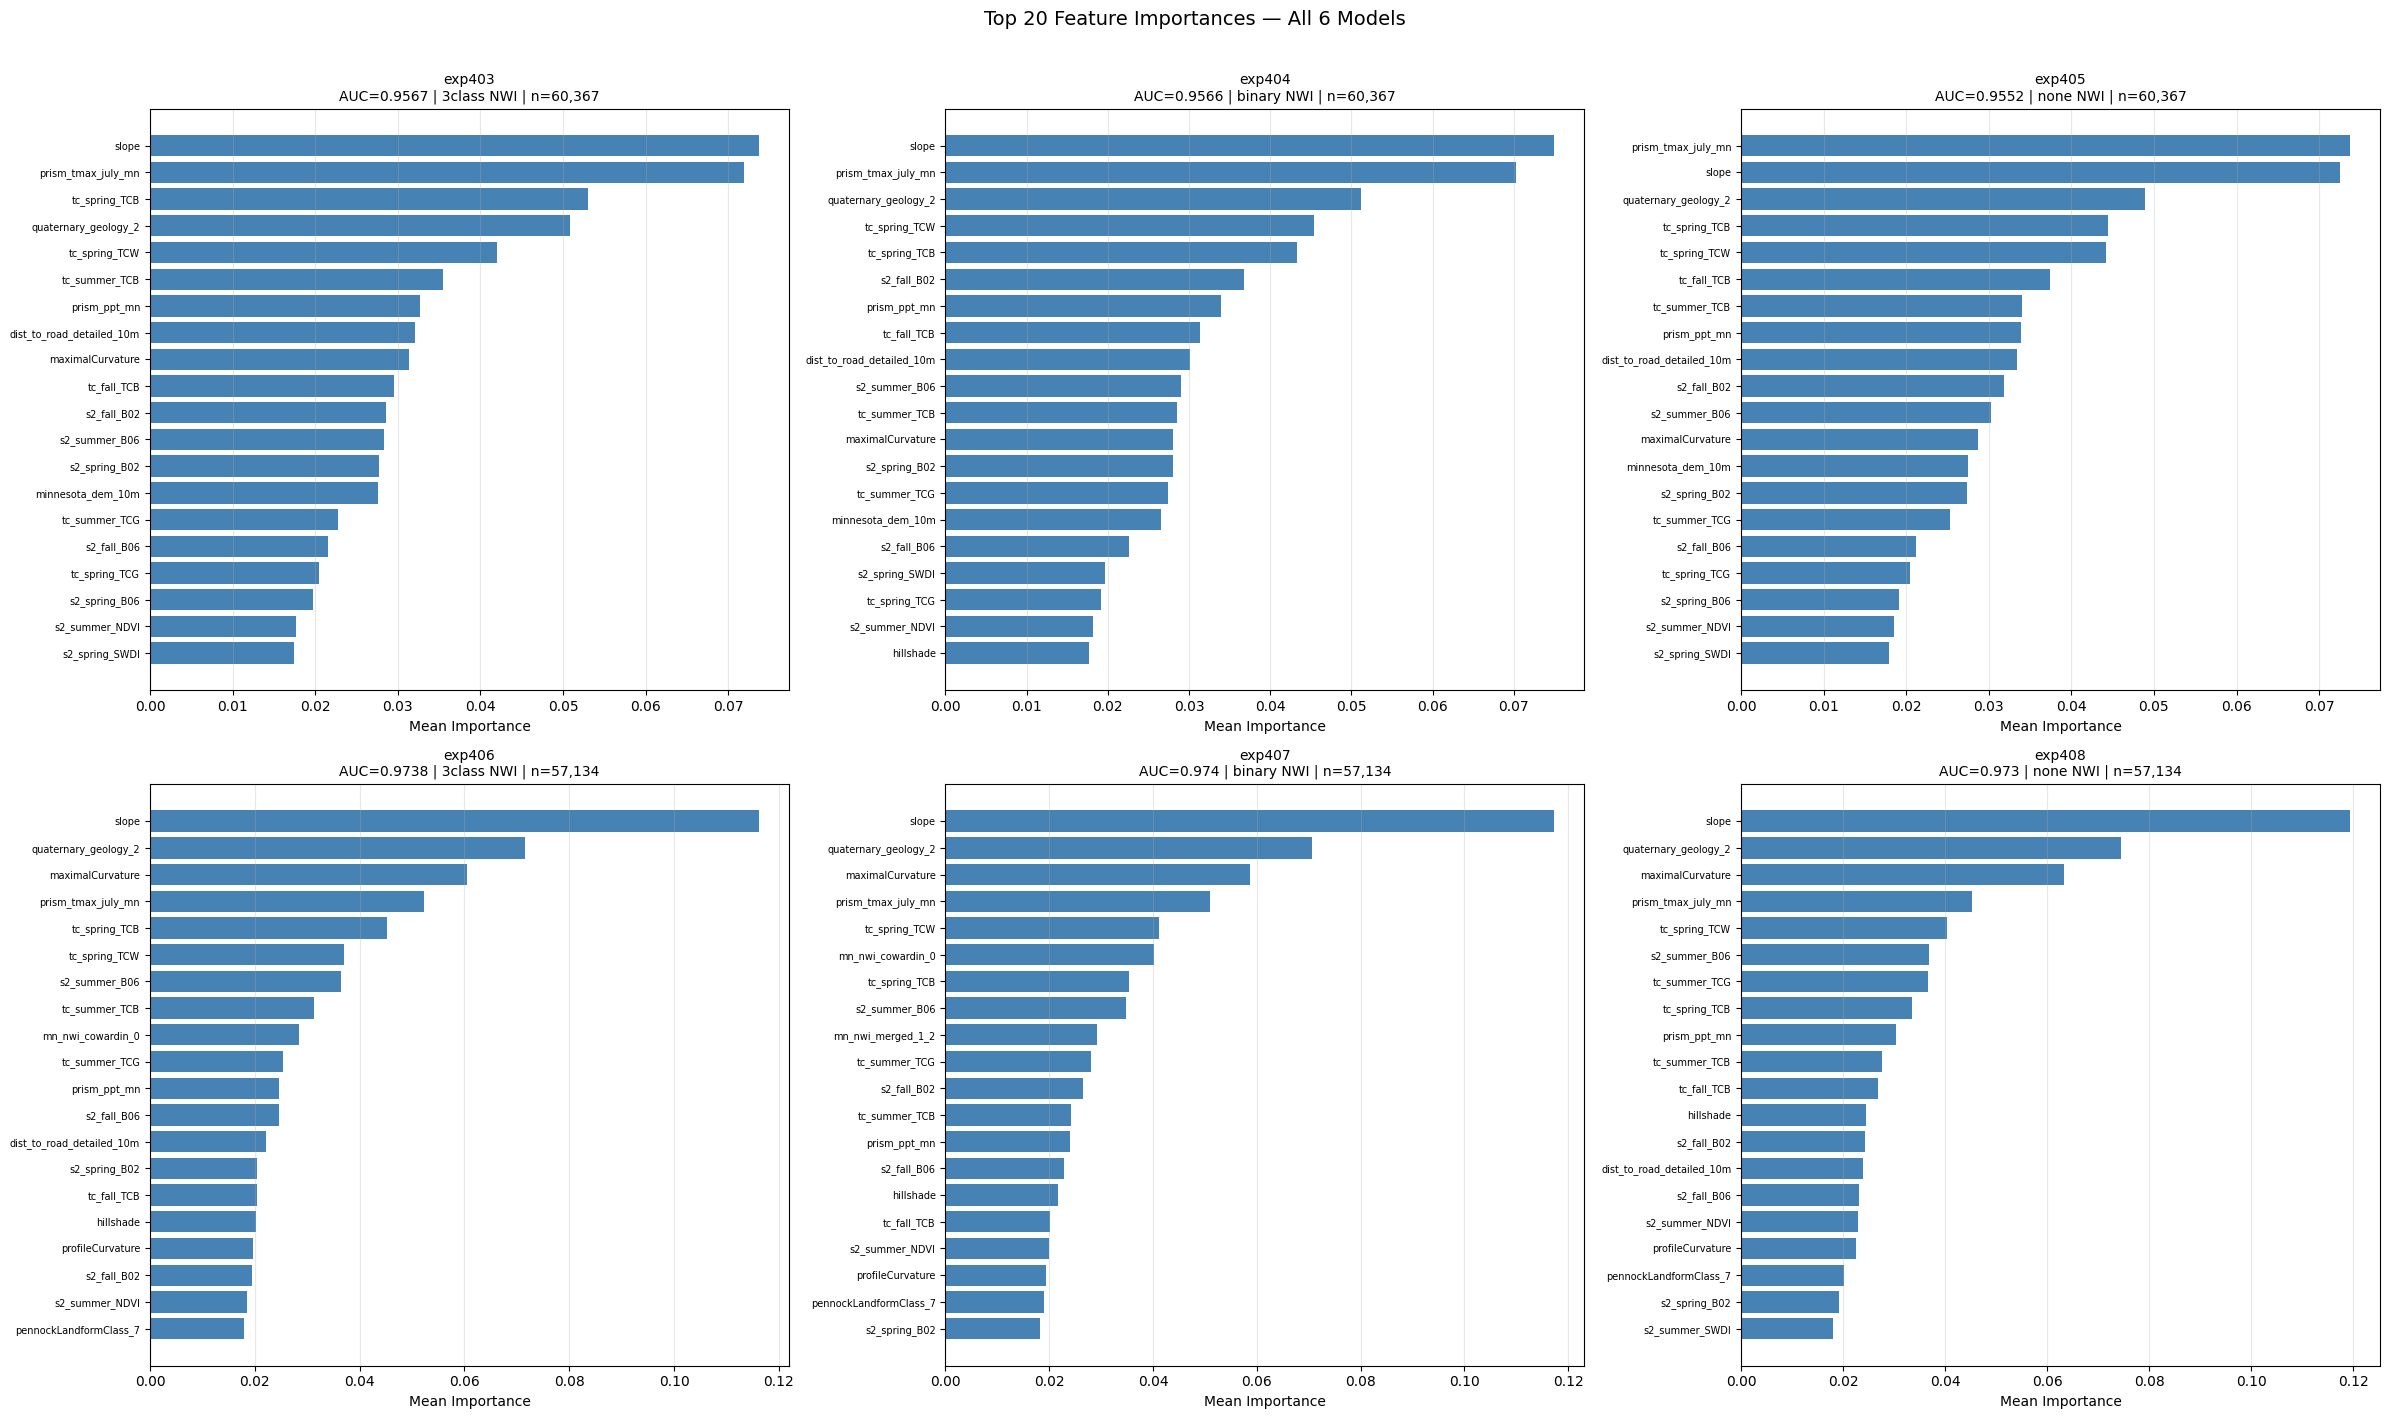

Saved: /scratch.global/ocon0444/peat_modeling/05_results/exp403_408_feature_importance.png


In [9]:
# Cell 9 — Feature importance plot for each model
fig, axes = plt.subplots(2, 3, figsize=(24, 14))
axes = axes.flatten()

for ax, (exp_id, res) in zip(axes, results.items()):
    # Average importance across all 5 fold models
    all_imp = np.mean(
        [m.feature_importances_ for m in res['models']], axis=0
    )
    imp_df = pd.DataFrame({
        'feature': res['feature_cols'],
        'importance': all_imp
    }).sort_values('importance', ascending=False).head(20)

    ax.barh(imp_df['feature'][::-1], imp_df['importance'][::-1], color='steelblue')
    ax.set_title(f"{exp_id}\nAUC={res['mean_roc_auc']} | {res['nwi_type']} NWI | n={res['n_samples']:,}",
                 fontsize=10)
    ax.set_xlabel('Mean Importance')
    ax.grid(alpha=0.3, axis='x')
    ax.tick_params(axis='y', labelsize=7)

plt.suptitle('Top 20 Feature Importances — All 6 Models', fontsize=14, y=1.01)
plt.tight_layout()

out_fig = os.path.join(BASE, '05_results/exp403_408_feature_importance.png')
os.makedirs(os.path.dirname(out_fig), exist_ok=True)
plt.savefig(out_fig, dpi=150, bbox_inches='tight')
plt.show()
print(f'Saved: {out_fig}')